RFM Shape:
(4338, 4)

First 5 Rows:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40

Customer Segments:
Segment
Lost Customers         1416
Champions              1139
Loyal Customers         821
At Risk                 643
Potential Loyalists     319
Name: count, dtype: int64


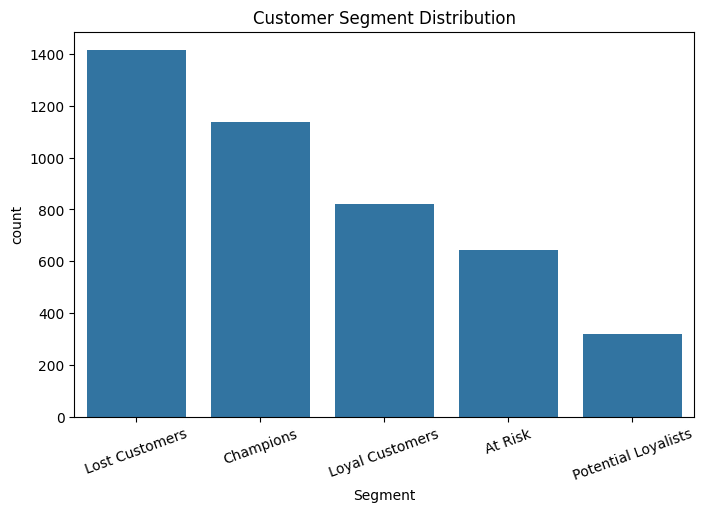


Revenue by Segment:
Segment
Champions              5913422.081
Loyal Customers        1351084.300
At Risk                 798052.511
Lost Customers          679430.262
Potential Loyalists     145219.740
Name: Monetary, dtype: float64


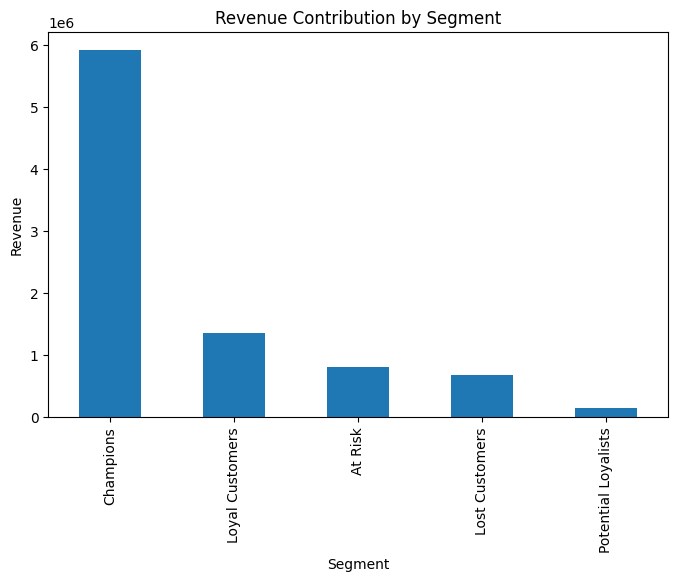


Customer Segmentation Completed!


In [1]:
# ==========================================
# CUSTOMER LIFETIME VALUE PROJECT
# PHASE 4: CUSTOMER SEGMENTATION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Load RFM Dataset
# ------------------------------------------

rfm = pd.read_csv("../data/customer_rfm.csv")

print("RFM Shape:")
print(rfm.shape)

print("\nFirst 5 Rows:")
print(rfm.head())

# ------------------------------------------
# Create RFM Scores
# ------------------------------------------

# Recency
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

# Frequency
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

# Monetary
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

# ------------------------------------------
# Combined RFM Score
# ------------------------------------------

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

# ------------------------------------------
# Customer Segments
# ------------------------------------------

def customer_segment(row):

    r = int(row["R_Score"])
    f = int(row["F_Score"])

    if r >= 4 and f >= 4:
        return "Champions"

    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    else:
        return "Lost Customers"


rfm["Segment"] = rfm.apply(
    customer_segment,
    axis=1
)

# ------------------------------------------
# Segment Distribution
# ------------------------------------------

segment_counts = (
    rfm["Segment"]
    .value_counts()
)

print("\nCustomer Segments:")
print(segment_counts)

# ------------------------------------------
# Visualization
# ------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="Segment",
    order=segment_counts.index
)

plt.title("Customer Segment Distribution")
plt.xticks(rotation=20)
plt.show()

# ------------------------------------------
# Segment Revenue Analysis
# ------------------------------------------

segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
       .sum()
       .sort_values(ascending=False)
)

print("\nRevenue by Segment:")
print(segment_revenue)

plt.figure(figsize=(8,5))

segment_revenue.plot(
    kind="bar"
)

plt.title("Revenue Contribution by Segment")
plt.ylabel("Revenue")
plt.show()

# ------------------------------------------
# Save Segmented Dataset
# ------------------------------------------

rfm.to_csv(
    "../data/customer_segments.csv",
    index=False
)

print("\nCustomer Segmentation Completed!")